In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
import yfinance as yf

stock = yf.download("AAPL", start="2020-01-01", end="2025-01-01", progress=True)
print(stock.shape)
print(stock.tail())

[*********************100%***********************]  1 of 1 completed

(1258, 5)
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
2024-12-24  256.560822  256.570737  253.669277  253.868019  23234700
2024-12-26  257.375580  258.448740  255.994420  256.550862  27237100
2024-12-27  253.967377  257.057649  251.453440  256.193146  42355300
2024-12-30  250.598892  251.890642  249.158101  250.628701  35557500
2024-12-31  248.830215  251.672059  247.846495  250.837396  39480700


In [3]:
# Get the closing price and calculate daily returns
close_prices = stock["Close"]["AAPL"]
daily_returns = close_prices.pct_change().dropna()

# Calculate our two key inputs
mu = daily_returns.mean()
sigma = daily_returns.std()

print(f"Daily average return: {mu:.6f}")
print(f"Daily volatility: {sigma:.6f}")

Daily average return: 0.001182
Daily volatility: 0.019956


In [4]:
# Simulation settings
S0 = float(close_prices.iloc[-1])  # Starting price (last known price)
T = 252                              # Number of trading days to simulate (1 year)
num_simulations = 1000               # How many possible futures to generate
dt = 1/252                           # One day as a fraction of a year

print(f"Starting price: ${S0:.2f}")
print(f"Simulating {num_simulations} paths over {T} trading days")

Starting price: $248.83
Simulating 1000 paths over 252 trading days


In [5]:
# Run the simulation
results = []  # This list will store all 1000 price paths

for i in range(num_simulations):        # outer loop: each simulation
    prices = [S0]                        # start each path at $248.83
    
    for t in range(T):                   # inner loop: each trading day
        Z = np.random.standard_normal()  # random number
        price = prices[-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
        prices.append(price)
    
    results.append(prices)

print(f"Simulation complete! Generated {len(results)} price paths.")

Simulation complete! Generated 1000 price paths.


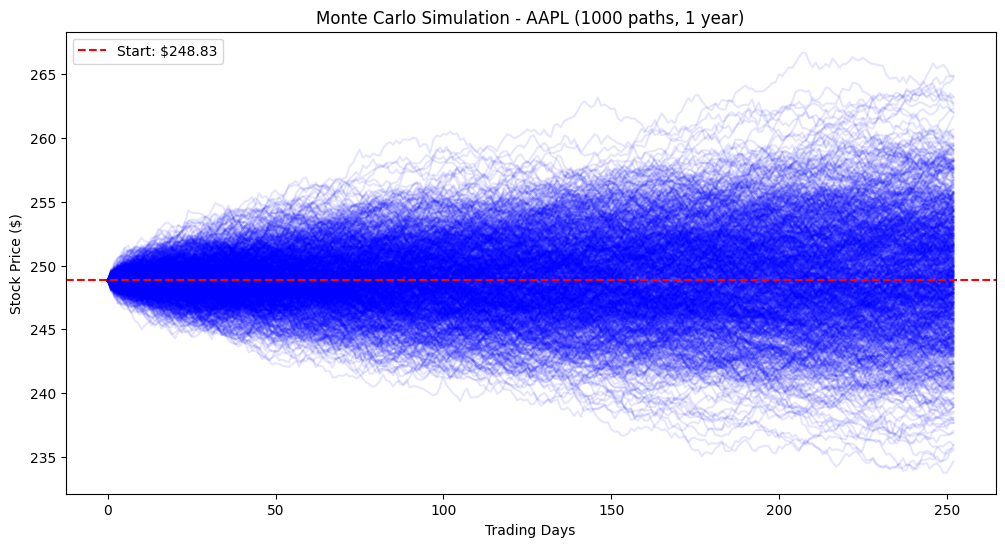

In [6]:
# Plot all 1000 price paths
plt.figure(figsize=(12, 6))

for path in results:
    plt.plot(path, alpha=0.1, color='blue')

plt.title("Monte Carlo Simulation - AAPL (1000 paths, 1 year)")
plt.xlabel("Trading Days")
plt.ylabel("Stock Price ($)")
plt.axhline(y=S0, color='red', linestyle='--', label=f'Start: ${S0:.2f}')
plt.legend()
plt.show()

In [7]:
import numpy as np

final_prices = [path[-1] for path in results]

print(f"Expected price:  ${np.mean(final_prices):.2f}")
print(f"Best case:       ${np.max(final_prices):.2f}")
print(f"Worst case:      ${np.min(final_prices):.2f}")
print(f"Prob of profit:  {(np.sum(np.array(final_prices) > S0) / num_simulations * 100):.1f}%")

Expected price:  $249.37
Best case:       $264.88
Worst case:      $234.64
Prob of profit:  54.4%
